# Generative Models

This notebook mplements and trains some generative models as the (feedforward) Deep Autoencoder and the Convolutional Autoencoder and how to use them to reconstruct data, e.g. image from original or noisy input.

In [70]:
#Setup
import keras
from keras import layers

In [71]:
# This is the size of our encoded representations
encoding_dim = 32  # 32 floats -> compression of factor 24.5, assuming the input is 784 floats

# This is our input image
input_img = keras.Input(shape=(784,))
# "encoded" is the encoded representation of the input
encoded = layers.Dense(encoding_dim, activation='relu')(input_img)
# "decoded" is the lossy reconstruction of the input
decoded = layers.Dense(784, activation='sigmoid')(encoded)


In [72]:
#Encoder model:
# This model maps an input to its encoded representation
encoder = keras.Model(input_img, encoded)
encoder.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        25,120 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,120 (98.12 KB)

 Trainable params: 25,120 (98.12 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
decoder = keras.Model(encoded, decoded)
decoder.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_26CLONE            │ (None, 32)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,872 (101.06 KB)

 Trainable params: 25,872 (101.06 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
# Autoencoder metwork
# This model maps an input to its reconstruction
autoencoder = keras.Model(input_img, decoded)
autoencoder.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
#Autoencoder model training configuration
# Use a per-pixel binary crossentropy loss, and the Adam optimizer:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


In [76]:
# Input data (MNIST digits image dataset)
# Note that the labels are discarded (replaced by _) since we're only interested in encoding/decoding the input images.

from keras.datasets import mnist
import numpy as np
(x_train, _), (x_test, _) = mnist.load_data()

In [77]:
# Preprocessing
# Normalize all values between 0 and 1 by dividing on the maximum pixel value (255)
# Flatten the images into vectors of size 28x28=784.

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)


(60000, 784)
(10000, 784)


In [78]:
# Training
# Train our autoencoder for 50 epochs:
# Note that the input data and the output targets are the same (x_train) since we aim at reconstructing the input

history = autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3836 - val_loss: 0.1913
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1809 - val_loss: 0.1519
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1474 - val_loss: 0.1323
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1301 - val_loss: 0.1200
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1189 - val_loss: 0.1116
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1112 - val_loss: 0.1063
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1061 - val_loss: 0.1016
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1018 - val_loss: 0.0983
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0990 - val_loss: 0.0963
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0973 - val_loss: 0.0950


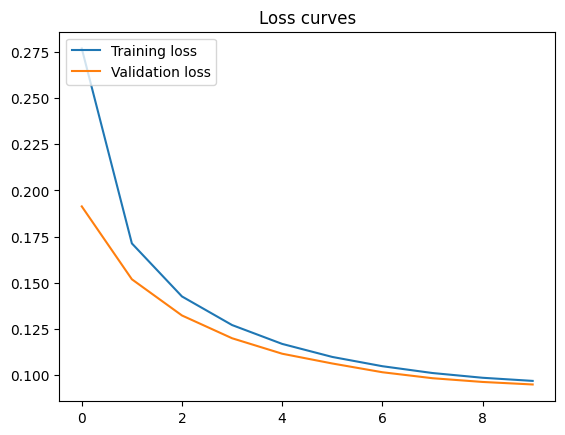

In [79]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label="Training loss")
plt.plot(history.history['val_loss'], label="Validation loss")
plt.title("Loss curves")
plt.legend(loc = "upper left")
plt.show()


In [80]:
# Reconstruction
# Encode the test set images
encoded_imgs = encoder.predict(x_test)
# Decode the encoded images
decoded_imgs = decoder.predict(encoded_imgs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


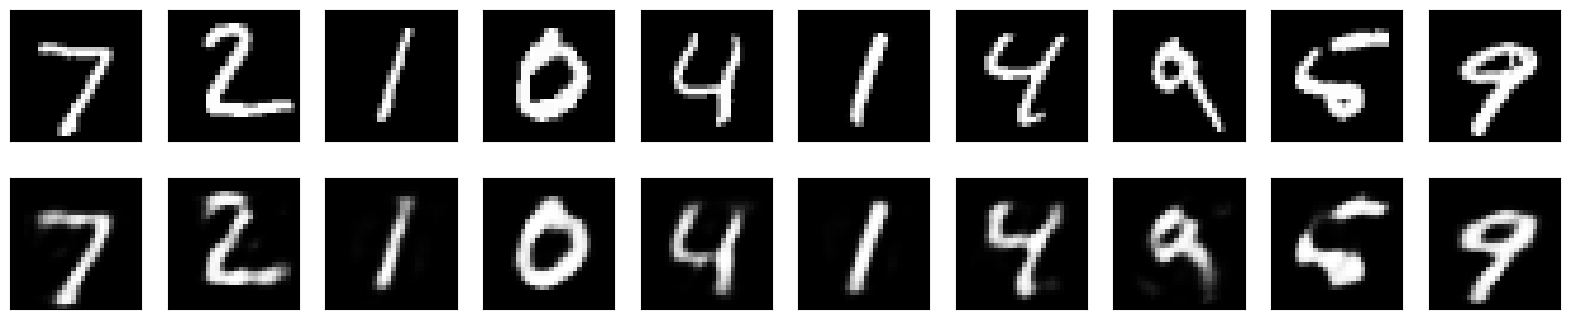

In [81]:
# Dispaly the original and the encoded-decoded images
import matplotlib.pyplot as plt

n = 10  # How many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


In [82]:
# Measure the reconstruction error
from sklearn.metrics import mean_squared_error
RMSE = np.sqrt(mean_squared_error(x_test, decoded_imgs))
Relative_MSE = RMSE/np.mean(x_test)
print("Root Mean Square Error: ", RMSE)
print("Relative MSE: ", Relative_MSE)


Root Mean Square Error:  0.10270463654482231
Relative MSE:  0.7750435190617503


# Exercise 1 - (Feedforward) Deep Autoencoder
In this exercise we aim at designing and training a deep autoencoder model for MNIST dataset.
The main difference with the simple autoencoder (see the Warm-up Example above) is the
architecture of the encoder and decoder networks, where several feedforward layers are stacked.

## Setup

In [83]:
#Setup
import keras
from keras import layers
from keras import regularizers
from json import decoder
from keras.datasets import mnist
import numpy as np

## Encoder config

In [84]:
# entrance layer
input_img = keras.Input(shape=(784,), name="input_img")

In [85]:
encoded = layers.Dense(128, activation='relu', name="enc_dense_128")(input_img)

In [86]:
encoded = layers.Dense(64, activation='relu', name="enc_dense_64")(encoded)

In [87]:
encoded = layers.Dense(32, activation='relu', name="latent_32")(encoded)

In [88]:
encoder = keras.Model(inputs=input_img, outputs=encoded, name="encoder")

In [89]:
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)          │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_128 (Dense)           │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_64 (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_32 (Dense)               │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,816 (432.88 KB)

 Trainable params: 110,816 (432.88 KB)

 Non-trainable params: 0 (0.00 B)

## Decoder config

In [90]:
decoded = layers.Dense(64, activation='relu', name="dec_dense_64")(encoded)

In [91]:
decoded = layers.Dense(128, activation='relu', name="dec_dense_128")(decoded)

In [92]:
decoded = layers.Dense(784, activation='sigmoid', name="reconstruction_784")(decoded)

In [93]:
decoder = keras.Model(inputs=encoded, outputs=decoded, name="decoder")

In [94]:
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_30CLONE            │ (None, 32)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_64 (Dense)            │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_128 (Dense)           │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction_784 (Dense)      │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,568 (435.81 KB)

 Trainable params: 111,568 (435.81 KB)

 Non-trainable params: 0 (0.00 B)

## Autoencoder - from start to end

In [95]:
autoencoder = keras.Model(inputs=input_img, outputs=decoded, name="autoencoder")

In [96]:
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)          │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_128 (Dense)           │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_64 (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_32 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_64 (Dense)            │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_128 (Dense)           │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction_784 (Dense)      │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

## Dataset

In [97]:
from tensorflow.keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()
print("Training images shape:", x_train.shape)
print("Test images shape:", x_test.shape)

Training images shape: (60000, 28, 28)
Test images shape: (10000, 28, 28)


## Train & Test

In [98]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

In [99]:
x_train = x_train.reshape((x_train.shape[0], 784))
x_test  = x_test.reshape((x_test.shape[0], 784))

print("Trainig set shape:", x_train.shape)  # match screenshot spelling if needed
print("Test set shape:", x_test.shape)

Trainig set shape: (60000, 784)
Test set shape: (10000, 784)


## Compile

It prepares the learning engine.

Why do you need to compile the model?

Because before training, Keras needs to know how to learn.

`compile()` is the moment when you tell the model:

“How will you adjust the weights when you make a mistake?”

-Without `compile()`, the model doesn't know:

- which function to measure the error (loss)

- how to update the weights (optimizer)

And therefore it cannot be trained.

If you try to run `fit()` without `compile()`, it will give an error.

In [100]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

## Fit

In [101]:
history = autoencoder.fit(
    x_train, x_train,          # input = output
    epochs=10,
    batch_size=512,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.3999 - val_loss: 0.2168
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.1985 - val_loss: 0.1614
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.1574 - val_loss: 0.1414
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.1399 - val_loss: 0.1306
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.1306 - val_loss: 0.1249
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.1250 - val_loss: 0.1203
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.1208 - val_loss: 0.1172
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.1176 - val_loss: 0.1141
Epoch 9/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.1149 - val_loss: 0.1115
Epoch 10/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.1120 - val_loss: 0.1088


In [102]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs_via_models = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [103]:
decoded_imgs_direct = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


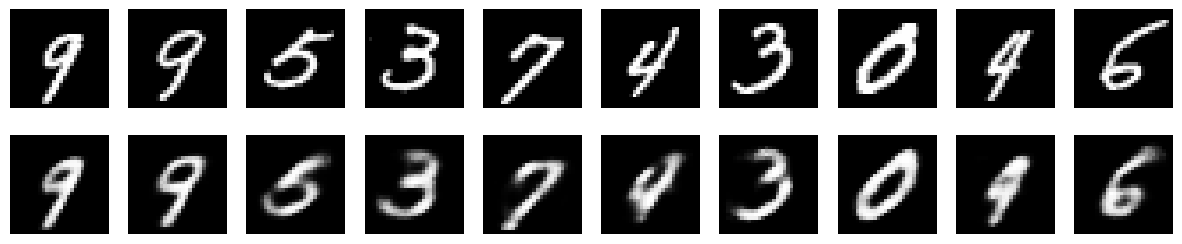

In [104]:

n = 10  # number of digits to show
idx = np.random.randint(0, x_test.shape[0] - n)  # random start index

# choose which reconstruction to display:
recon = decoded_imgs_direct   # or decoded_imgs_via_models

plt.figure(figsize=(15, 3))

# Top row: original
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[idx + i].reshape(28, 28), cmap="gray")
    plt.axis("off")

# Bottom row: reconstructed
for i in range(n):
    ax = plt.subplot(2, n, n + i + 1)
    plt.imshow(recon[idx + i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()

# Exercise 2 - Convolutional Autoencoder

### Encoder layer

In [105]:
from tensorflow import keras
from tensorflow.keras import layers

# 1.1 Input layer (28, 28, 1)
input_img = keras.Input(shape=(28, 28, 1), name="input_img")

# 1.2 Encoder layers
x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(input_img)
x = layers.MaxPooling2D((2, 2), padding="same")(x)

x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)

x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D((2, 2), padding="same", name="encoded")(x)  # (None, 4, 4, 8)

# 1.3 Build encoder model
encoder = keras.Model(inputs=input_img, outputs=encoded, name="encoder")

# 1.4 Show encoder summary
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)          │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 4, 4, 8)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,904 (7.44 KB)

 Trainable params: 1,904 (7.44 KB)

 Non-trainable params: 0 (0.00 B)

### Decoder layer

In [106]:
# 2.1 Decoder layers (input is the encoder output "encoded")
x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(encoded)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(16, (3, 3), activation="relu", padding="valid")(x)
x = layers.UpSampling2D((2, 2))(x)

# Output layer: 1 filter, sigmoid, same padding
decoded = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="decoded")(x)

# 2.2 Build decoder model
decoder = keras.Model(inputs=encoded, outputs=decoded, name="decoder")

# Show decoder summary
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_39CLONE            │ (None, 4, 4, 8)        │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,481 (9.69 KB)

 Trainable params: 2,481 (9.69 KB)

 Non-trainable params: 0 (0.00 B)

### Full Convolutional Autoencoder Model

In [107]:
# 3.1 Full CAE model
autoencoder = keras.Model(inputs=input_img, outputs=decoded, name="convolutional_autoencoder")

# 3.2 Summary
autoencoder.summary()

Model: "convolutional_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)          │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

### Train

In [108]:
from tensorflow.keras.datasets import mnist
import numpy as np

# 4.1 Load MNIST (ignore labels)
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# 4.2 Reshape to include channel dimension
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test  = np.reshape(x_test,  (len(x_test),  28, 28, 1))

print("x_train size:", x_train.shape)
print("x_test size:", x_test.shape)

x_train size: (60000, 28, 28, 1)
x_test size: (10000, 28, 28, 1)


In [110]:
# Compile
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

# Train
history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=512,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 61s 490ms/step - loss: 0.3882 - val_loss: 0.2052
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 81s 482ms/step - loss: 0.1923 - val_loss: 0.1671
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 57s 481ms/step - loss: 0.1638 - val_loss: 0.1526
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 83s 486ms/step - loss: 0.1512 - val_loss: 0.1448
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 82s 491ms/step - loss: 0.1440 - val_loss: 0.1392
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 58s 489ms/step - loss: 0.1388 - val_loss: 0.1344
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 81s 484ms/step - loss: 0.1346 - val_loss: 0.1302
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 59s 496ms/step - loss: 0.1302 - val_loss: 0.1265
Epoch 9/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 57s 482ms/step - loss: 0.1267 - val_loss: 0.1236
Epoch 10/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 84s 502ms/step - loss: 0.1238 - val_loss: 0.1213


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


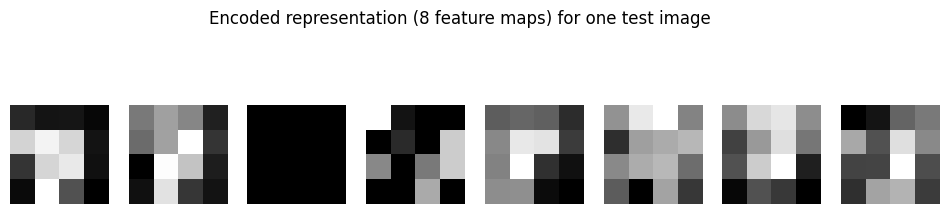

In [111]:
encoded_imgs = encoder.predict(x_test)  # shape: (10000, 4, 4, 8)

# Visualize: for the first sample, show the 8 feature maps (4x4 each)
sample = 0
plt.figure(figsize=(12, 3))
for i in range(8):
    ax = plt.subplot(1, 8, i + 1)
    plt.imshow(encoded_imgs[sample, :, :, i], cmap="gray")
    plt.axis("off")
plt.suptitle("Encoded representation (8 feature maps) for one test image")
plt.show()


### Test

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


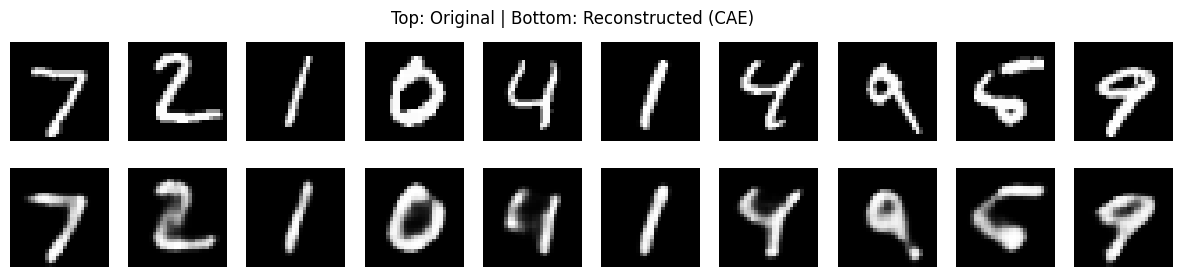

In [112]:
reconstructed = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(15, 3))

# originals
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

# reconstructions
for i in range(n):
    ax = plt.subplot(2, n, n + i + 1)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Top: Original | Bottom: Reconstructed (CAE)")
plt.show()

#  Exercise 3 - Image denoising using Convolutional Autoencoder (CAE)

### Add noise to MNIST

x_train: (60000, 28, 28, 1) 0.0 1.0
x_test : (10000, 28, 28, 1) 0.0 1.0


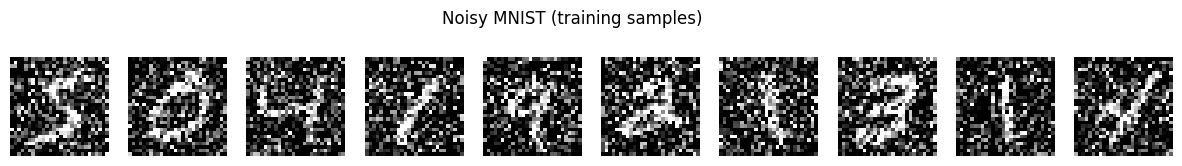

In [113]:
# Make sure x_train/x_test are float32 in [0,1] and shape (N,28,28,1)
print("x_train:", x_train.shape, x_train.min(), x_train.max())
print("x_test :", x_test.shape,  x_test.min(),  x_test.max())

# 1.1 Create random noise vectors (Gaussian)
noise_train = np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
noise_test  = np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# 1.2 Multiply by noise factor
noise_factor = 0.5
noise_train *= noise_factor
noise_test  *= noise_factor

# 1.3 Add noise to images
x_train_noisy = x_train + noise_train
x_test_noisy  = x_test  + noise_test

# 1.4 Clip back to [0, 1]
x_train_noisy = np.clip(x_train_noisy, a_min=0.0, a_max=1.0)
x_test_noisy  = np.clip(x_test_noisy,  a_min=0.0, a_max=1.0)

# 1.5 Visualize some noisy training images
n = 10
plt.figure(figsize=(15, 2))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.suptitle("Noisy MNIST (training samples)")
plt.show()


### Train the CAE for denoising (noisy input → clean output)

In [114]:
# Compile (same as before)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

# Train denoising autoencoder
history = autoencoder.fit(
    x_train_noisy, x_train,            # noisy -> clean
    epochs=10,
    batch_size=512,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 63s 507ms/step - loss: 0.2099 - val_loss: 0.1638
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 61s 521ms/step - loss: 0.1628 - val_loss: 0.1568
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 60s 510ms/step - loss: 0.1572 - val_loss: 0.1532
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 82s 509ms/step - loss: 0.1539 - val_loss: 0.1507
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 60s 509ms/step - loss: 0.1519 - val_loss: 0.1490
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 81s 501ms/step - loss: 0.1500 - val_loss: 0.1479
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 61s 518ms/step - loss: 0.1485 - val_loss: 0.1463
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 58s 495ms/step - loss: 0.1476 - val_loss: 0.1448
Epoch 9/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 61s 514ms/step - loss: 0.1460 - val_loss: 0.1435
Epoch 10/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 59s 504ms/step - loss: 0.1448 - val_loss: 0.1425


### Test + visualize (noisy test vs denoised output)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


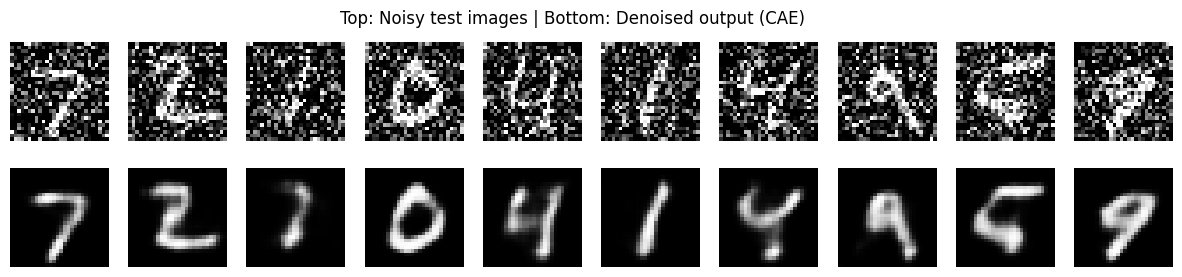

In [115]:
# Predict denoised images from noisy test set
x_test_denoised = autoencoder.predict(x_test_noisy)

# Visualize: top row noisy, bottom row denoised (like the PDF)
n = 10
plt.figure(figsize=(15, 3))

for i in range(n):
    # Noisy
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

for i in range(n):
    # Denoised output
    ax = plt.subplot(2, n, n + i + 1)
    plt.imshow(x_test_denoised[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Top: Noisy test images | Bottom: Denoised output (CAE)")
plt.show()

#### three rows (clean vs noisy vs denoised) for clarity

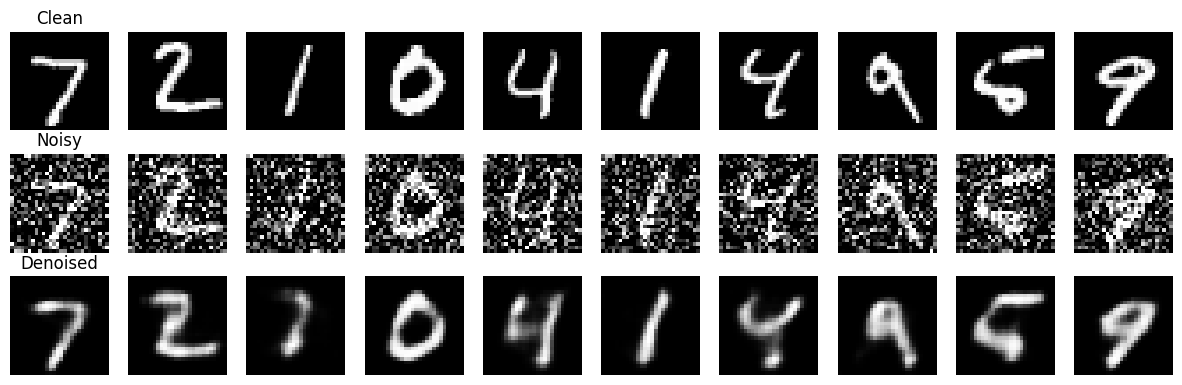

In [116]:
n = 10
plt.figure(figsize=(15, 4.5))

for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("Clean")

for i in range(n):
    ax = plt.subplot(3, n, n + i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("Noisy")

for i in range(n):
    ax = plt.subplot(3, n, 2*n + i + 1)
    plt.imshow(x_test_denoised[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("Denoised")

plt.show()